# Chapter 8 Visualizations

This notebook generates the final visuals for **Chapter 8: Results Visualization and Interpretation**.

Figures included:

1. **Figure 8.1:** Overall Model Performance Comparison  
2. **Figure 8.2:** Full Test Set Model Comparison  
3. **Figure 8.3:** Confusion Matrix Comparison Across Models  
4. **Figure 8.4:** Fresh and Rotten Aspect-Opinion Pair Charts  

**Important:** Figure 8.4 requires `fresh_absa_results.csv` and `rotten_absa_results.csv` from the BERT notebook. Put those two CSV files in the same folder as this notebook before running the ABSA visualization cell.


## 1. Import Libraries and Create Output Folder

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create output folder for saved figures
OUTPUT_DIR = "chapter8_figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Figures will be saved in:", OUTPUT_DIR)

Figures will be saved in: chapter8_figures


## 2. Model Performance Data

The values below are manually combined from the separate modelling notebooks / report outputs.

In [2]:
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM", "BERT", "BiLSTM"],
    "Approach": [
        "TF-IDF + Traditional ML",
        "TF-IDF + Traditional ML",
        "Transformer",
        "Deep Learning"
    ],
    "Test Size": [136707, 136707, 1000, 136707],
    "Accuracy": [0.7720, 0.7717, 0.8500, 0.8415],
    "F1-Score": [0.7720, 0.7717, 0.8497, 0.8413]
})

model_results

,Model,Approach,Test Size,Accuracy,F1-Score
0,Logistic Regression,TF-IDF + Traditional ML,136707,0.7720,0.7720
1,Linear SVM,TF-IDF + Traditional ML,136707,0.7717,0.7717
2,BERT,Transformer,1000,0.8500,0.8497
3,BiLSTM,Deep Learning,136707,0.8415,0.8413


## Figure 8.1: Overall Model Performance Comparison

This figure compares all models, including BERT. BERT is included here because this is the overall comparison across modelling approaches.

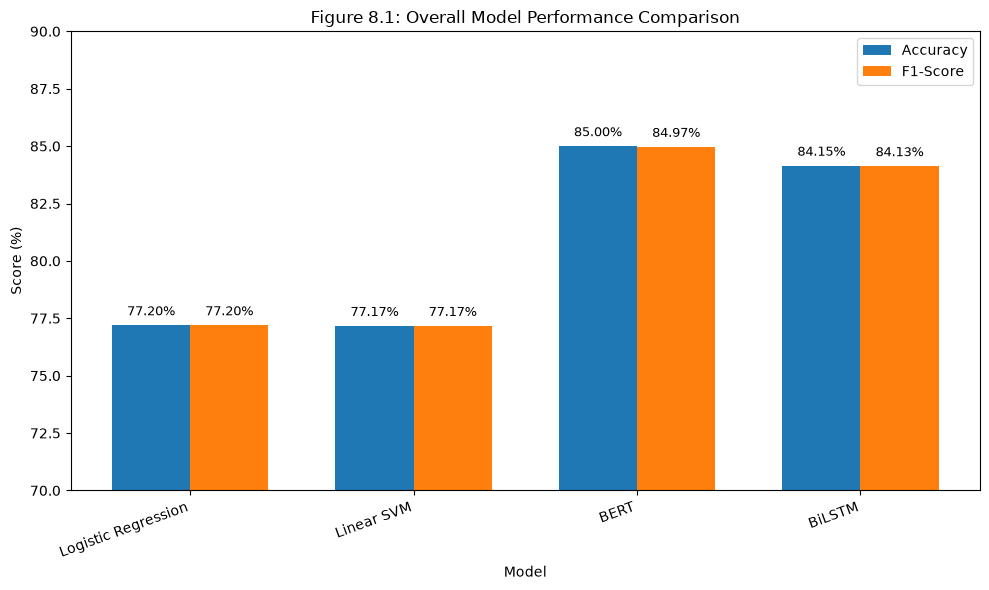

Saved: chapter8_figures\figure_8_1_overall_model_performance_comparison.png


In [3]:
plot_df = model_results.copy()
plot_df["Accuracy (%)"] = plot_df["Accuracy"] * 100
plot_df["F1-Score (%)"] = plot_df["F1-Score"] * 100

x = np.arange(len(plot_df["Model"]))
width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(x - width/2, plot_df["Accuracy (%)"], width, label="Accuracy")
bars2 = plt.bar(x + width/2, plot_df["F1-Score (%)"], width, label="F1-Score")

plt.title("Figure 8.1: Overall Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score (%)")
plt.xticks(x, plot_df["Model"], rotation=20, ha="right")
plt.ylim(70, 90)
plt.legend()

# Value labels
for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "figure_8_1_overall_model_performance_comparison.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

## Figure 8.2: Full Test Set Model Comparison

This figure compares only the models evaluated using the same full test size of **136,707 reviews**. BERT is excluded here because it was evaluated on a smaller sampled test set of **1,000 reviews**.

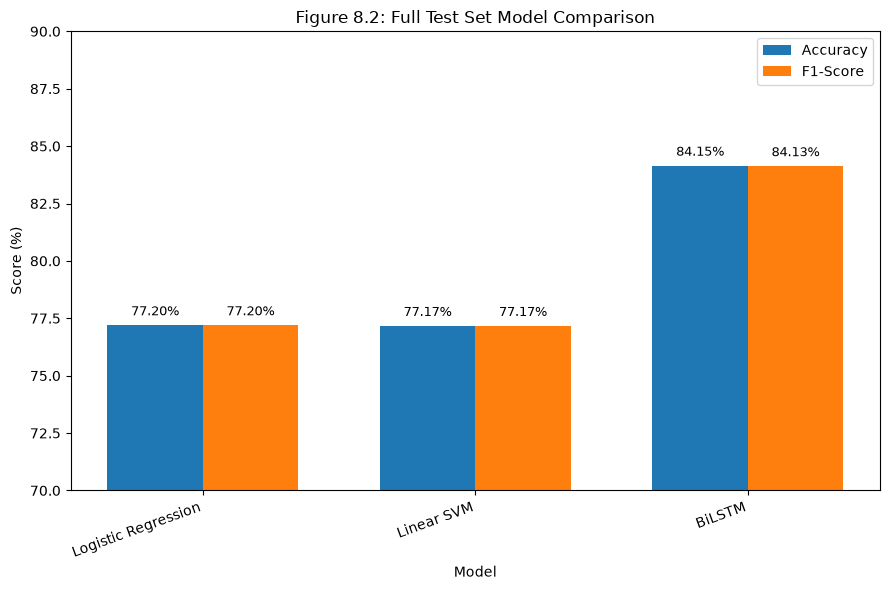

Saved: chapter8_figures\figure_8_2_full_test_set_model_comparison.png


In [4]:
full_test_df = model_results[model_results["Test Size"] == 136707].copy()
full_test_df["Accuracy (%)"] = full_test_df["Accuracy"] * 100
full_test_df["F1-Score (%)"] = full_test_df["F1-Score"] * 100

x = np.arange(len(full_test_df["Model"]))
width = 0.35

plt.figure(figsize=(9, 6))

bars1 = plt.bar(x - width/2, full_test_df["Accuracy (%)"], width, label="Accuracy")
bars2 = plt.bar(x + width/2, full_test_df["F1-Score (%)"], width, label="F1-Score")

plt.title("Figure 8.2: Full Test Set Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score (%)")
plt.xticks(x, full_test_df["Model"], rotation=20, ha="right")
plt.ylim(70, 90)
plt.legend()

# Value labels
for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "figure_8_2_full_test_set_model_comparison.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

## Figure 8.3: Confusion Matrix Comparison Across Models

This figure compares the confusion matrices for Logistic Regression, BERT, and BiLSTM.

Note: BERT uses a smaller sampled test set, so its total count is lower than Logistic Regression and BiLSTM.

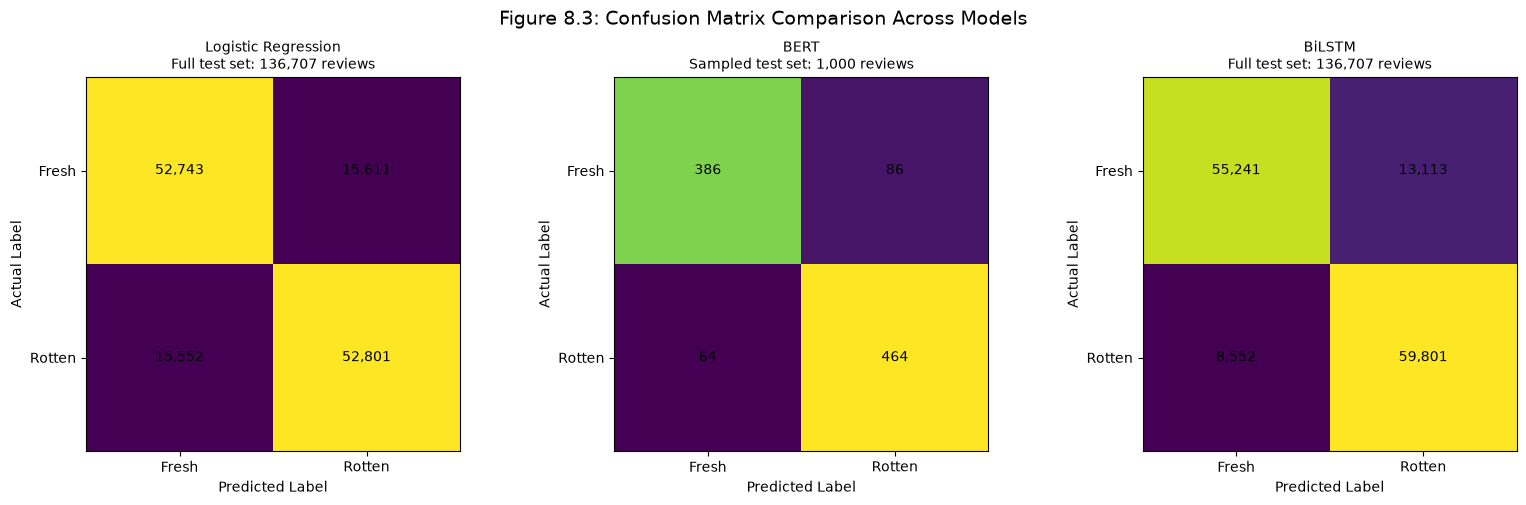

Saved: chapter8_figures\figure_8_3_confusion_matrix_comparison_across_models.png


In [5]:
# Confusion matrices
# Format:
# [[Actual Fresh predicted Fresh, Actual Fresh predicted Rotten],
#  [Actual Rotten predicted Fresh, Actual Rotten predicted Rotten]]

lr_cm = np.array([
    [52743, 15611],
    [15552, 52801]
])

bert_cm = np.array([
    [386, 86],
    [64, 464]
])

bilstm_cm = np.array([
    [55241, 13113],
    [8552, 59801]
])

labels = ["Fresh", "Rotten"]

cms = [
    ("Logistic Regression", lr_cm, "Full test set: 136,707 reviews"),
    ("BERT", bert_cm, "Sampled test set: 1,000 reviews"),
    ("BiLSTM", bilstm_cm, "Full test set: 136,707 reviews")
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (title, cm, subtitle) in zip(axes, cms):
    ax.imshow(cm)
    ax.set_title(title + "\n" + subtitle, fontsize=10)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                f"{cm[i, j]:,}",
                ha="center",
                va="center",
                fontsize=10
            )

plt.suptitle("Figure 8.3: Confusion Matrix Comparison Across Models", fontsize=14)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "figure_8_3_confusion_matrix_comparison_across_models.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

## Figure 8.4: Fresh and Rotten Aspect-Opinion Pair Charts

This figure requires:

- `fresh_absa_results.csv`
- `rotten_absa_results.csv`

Both files should have at least these columns:

- `aspect`
- `opinion`
- `count`

These files are generated from the BERT / aspect-opinion extraction notebook.

In [7]:
fresh_file = "fresh_absa_results.csv"
rotten_file = "rotten_absa_results.csv"

def prepare_absa_pairs(file_path):
    df = pd.read_csv(file_path)
    print(f"Loaded: {file_path}")
    print("Columns:", df.columns.tolist())
    
    # Normalize column names for safer matching
    column_map = {col.lower().strip(): col for col in df.columns}
    
    if "aspect" not in column_map:
        raise ValueError(f"No 'aspect' column found in {file_path}. Columns found: {df.columns.tolist()}")
    if "opinion" not in column_map:
        raise ValueError(f"No 'opinion' column found in {file_path}. Columns found: {df.columns.tolist()}")
    
    aspect_col = column_map["aspect"]
    opinion_col = column_map["opinion"]
    
    count_col = None
    for possible in ["count", "frequency", "freq"]:
        if possible in column_map:
            count_col = column_map[possible]
            break
    
    temp = df.copy()
    temp["Aspect-Opinion Pair"] = (
        temp[opinion_col].astype(str) + " " + temp[aspect_col].astype(str)
    )
    
    if count_col is None:
        pair_df = temp["Aspect-Opinion Pair"].value_counts().reset_index()
        pair_df.columns = ["Aspect-Opinion Pair", "Frequency"]
    else:
        pair_df = temp.groupby("Aspect-Opinion Pair", as_index=False)[count_col].sum()
        pair_df = pair_df.rename(columns={count_col: "Frequency"})
    
    pair_df = pair_df.sort_values("Frequency", ascending=False)
    return pair_df


if os.path.exists(fresh_file) and os.path.exists(rotten_file):
    fresh_pairs = prepare_absa_pairs(fresh_file)
    rotten_pairs = prepare_absa_pairs(rotten_file)
    
    print("\nTop Fresh pairs:")
    display(fresh_pairs.head(10))
    
    print("\nTop Rotten pairs:")
    display(rotten_pairs.head(10))

else:
    print("ABSA CSV files not found.")
    print("Please put fresh_absa_results.csv and rotten_absa_results.csv in the same folder as this notebook.")

Loaded: fresh_absa_results.csv
Columns: ['aspect', 'opinion', 'count']
Loaded: rotten_absa_results.csv
Columns: ['aspect', 'opinion', 'count']

Top Fresh pairs:


,Aspect-Opinion Pair,Frequency
1328,full review,31
2980,romantic comedy,12
1247,first time,9
221,best films,9
1231,first film,9
220,best film,9
1453,good movie,7
1630,high school,7
3285,special effects,7
3597,true story,7



Top Rotten pairs:


,Aspect-Opinion Pair,Frequency
1224,full review,24
2959,special effects,11
275,big screen,9
1107,first film,7
1128,first time,6
1306,good intentions,6
181,bad film,5
190,bad movie,5
437,cinematic equivalent,5
1867,main character,5


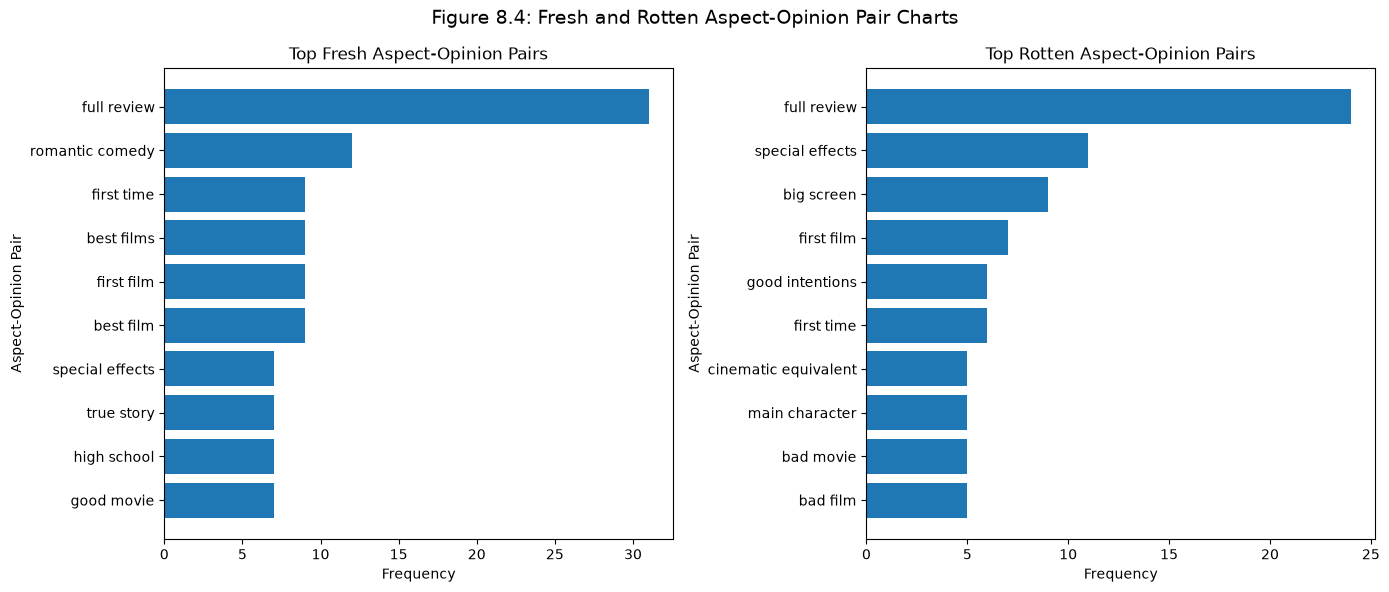

Saved: chapter8_figures\figure_8_4_fresh_rotten_aspect_opinion_pairs.png


In [8]:
if os.path.exists(fresh_file) and os.path.exists(rotten_file):
    top_n = 10
    fresh_top = fresh_pairs.head(top_n).sort_values("Frequency", ascending=True)
    rotten_top = rotten_pairs.head(top_n).sort_values("Frequency", ascending=True)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    axes[0].barh(fresh_top["Aspect-Opinion Pair"], fresh_top["Frequency"])
    axes[0].set_title("Top Fresh Aspect-Opinion Pairs")
    axes[0].set_xlabel("Frequency")
    axes[0].set_ylabel("Aspect-Opinion Pair")
    
    axes[1].barh(rotten_top["Aspect-Opinion Pair"], rotten_top["Frequency"])
    axes[1].set_title("Top Rotten Aspect-Opinion Pairs")
    axes[1].set_xlabel("Frequency")
    axes[1].set_ylabel("Aspect-Opinion Pair")
    
    plt.suptitle("Figure 8.4: Fresh and Rotten Aspect-Opinion Pair Charts", fontsize=14)
    plt.tight_layout()
    
    save_path = os.path.join(OUTPUT_DIR, "figure_8_4_fresh_rotten_aspect_opinion_pairs.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved:", save_path)
else:
    print("Figure 8.4 was not generated because the ABSA CSV files were not found.")

## 5. Check Saved Figures

In [9]:
print("Saved files in", OUTPUT_DIR)
for file in sorted(os.listdir(OUTPUT_DIR)):
    print("-", file)

Saved files in chapter8_figures
- figure_8_1_overall_model_performance_comparison.png
- figure_8_2_full_test_set_model_comparison.png
- figure_8_3_confusion_matrix_comparison_across_models.png
- figure_8_4_fresh_rotten_aspect_opinion_pairs.png
